In [2]:
!pip install imblearn

In [1]:
# =============================
# IMPORTS
# =============================
import os
import time
import psutil

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE



In [2]:
# =============================
# DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [3]:
# =============================
# DATA PATH
# =============================
DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"


In [4]:
# =============================
# CLEANING
# =============================
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df


df = clean_dataframe(pd.read_csv(DATA_PATH))


In [5]:
# =============================
# DATASET
# =============================
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [6]:
# =============================
# SIMPLE GNN LAYER
# =============================
class SimpleGNNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        num_features = x.shape[1]
        A = torch.ones((num_features, num_features), device=x.device) / num_features
        x = torch.matmul(x, A)
        return torch.relu(self.linear(x))


In [7]:
# =============================
# MODEL: CNN + LSTM + GNN (GATED)
# =============================
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, hidden_dim)

        # LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # GNN
        self.gnn1 = SimpleGNNLayer(input_dim, hidden_dim)
        self.gnn2 = SimpleGNNLayer(hidden_dim, hidden_dim)

        # ✅ GATED FUSION
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),
            nn.Sigmoid()
        )

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # GNN
        gnn_feat = self.gnn1(x)
        gnn_feat = self.gnn2(gnn_feat)

        # CONCAT
        combined = torch.cat([cnn_feat, lstm_feat, gnn_feat], dim=1)

        # GATES
        gates = self.gate(combined)

        g1 = gates[:, 0].unsqueeze(1)
        g2 = gates[:, 1].unsqueeze(1)
        g3 = gates[:, 2].unsqueeze(1)

        # FUSION
        fused = g1 * cnn_feat + g2 * lstm_feat + g3 * gnn_feat

        logits = self.classifier(fused)

        return torch.softmax(logits, dim=1)


In [8]:

# =============================
# TRAIN FUNCTION
# =============================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)

        log_outputs = torch.log(outputs + 1e-9)
        loss = criterion(log_outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total


In [9]:

# =============================
# EVALUATION
# =============================
def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)

            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(outputs.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs



In [10]:
# =============================
# MAIN PIPELINE
# =============================
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # BEFORE SAMPLING
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} BEFORE")
    plt.show()

    # SMOTE
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title=f"{ratio_name} AFTER SMOTE")
    plt.show()

    # SCALING
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # LOADERS
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # MODEL
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # TRAIN LOOP
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # LOSS + ACC
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # CONFUSION MATRIX
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()

    print(classification_report(true, preds))

    # ROC
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC")
    plt.show()

    # PR CURVE
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} PR Curve")
    plt.show()

    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")




========== 60:40 ==========


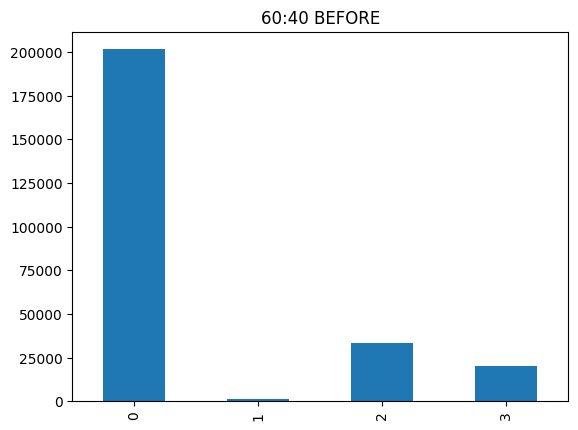

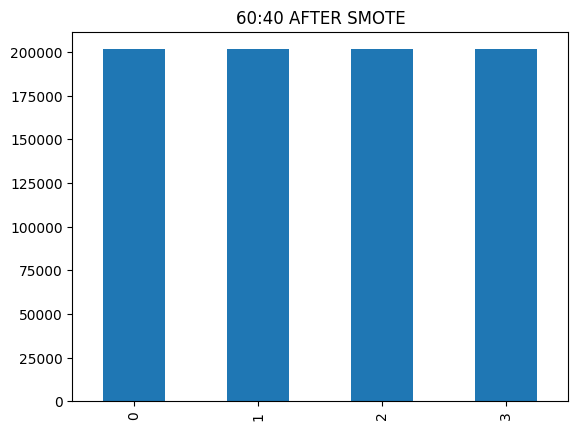

Epoch 1: Loss=0.0579, TrainAcc=0.9807, TestAcc=0.9789, ROC-AUC=0.9992
Epoch 2: Loss=0.0276, TrainAcc=0.9914, TestAcc=0.9847, ROC-AUC=0.9994
Epoch 3: Loss=0.0242, TrainAcc=0.9926, TestAcc=0.9841, ROC-AUC=0.9994
Epoch 4: Loss=0.0221, TrainAcc=0.9932, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 5: Loss=0.0209, TrainAcc=0.9937, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 6: Loss=0.0203, TrainAcc=0.9938, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 7: Loss=0.0196, TrainAcc=0.9941, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 8: Loss=0.0192, TrainAcc=0.9942, TestAcc=0.9850, ROC-AUC=0.9994
Epoch 9: Loss=0.0189, TrainAcc=0.9943, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 10: Loss=0.0184, TrainAcc=0.9944, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 11: Loss=0.0182, TrainAcc=0.9946, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 13: Loss=0.0176, TrainAcc=0.9947, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 14: Loss=0.0174, TrainAcc=0.9947, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 15: Loss=

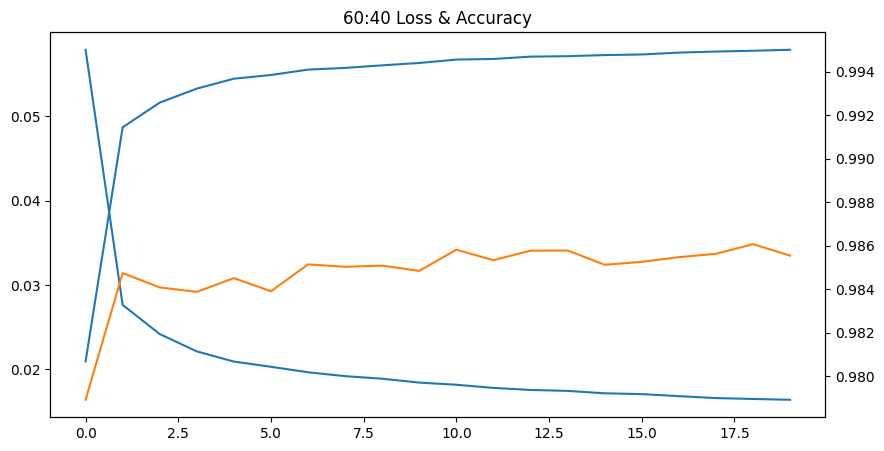

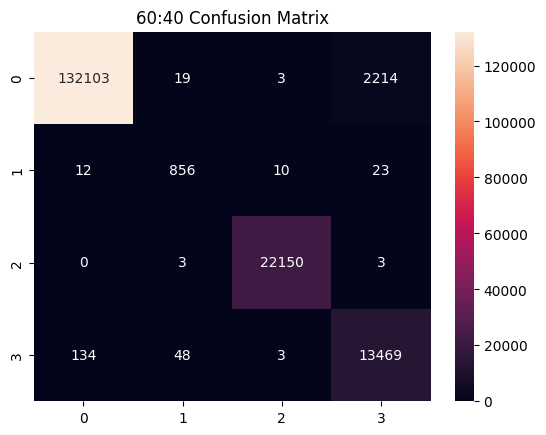

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.92      0.95      0.94       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.98      0.96    171050
weighted avg       0.99      0.99      0.99    171050



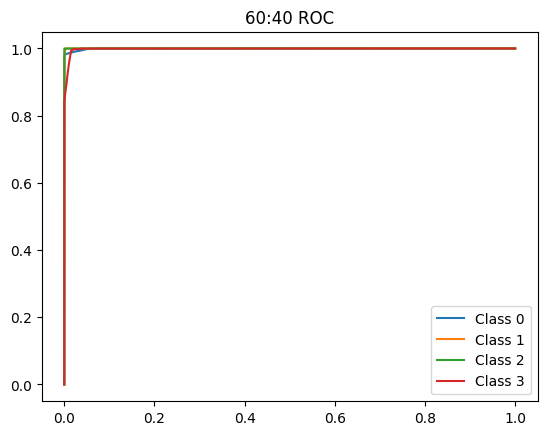

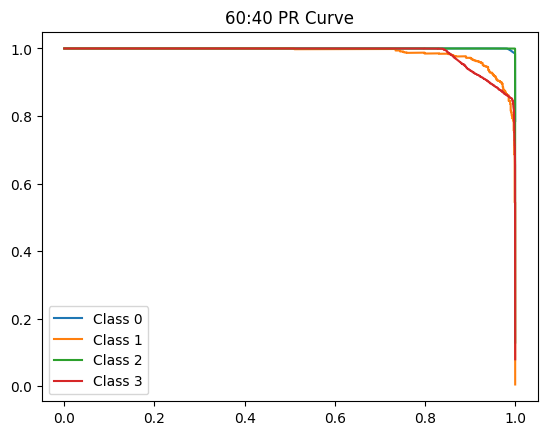

Runtime: 1277.65s
RAM Used: 1164.67 MB

========== 70:30 ==========


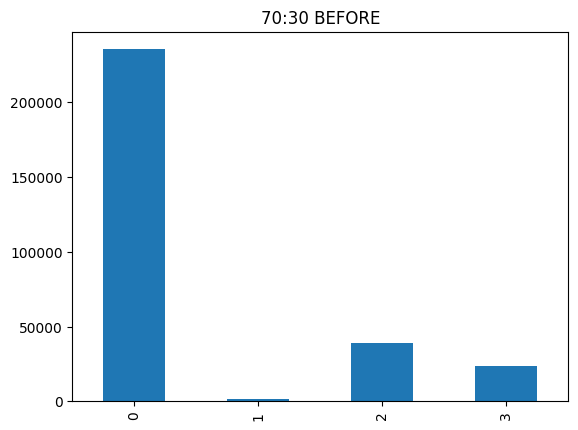

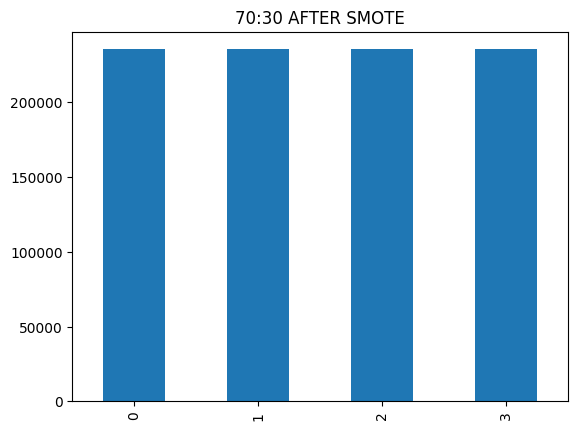

Epoch 1: Loss=0.0514, TrainAcc=0.9828, TestAcc=0.9773, ROC-AUC=0.9993
Epoch 2: Loss=0.0254, TrainAcc=0.9921, TestAcc=0.9833, ROC-AUC=0.9995
Epoch 3: Loss=0.0230, TrainAcc=0.9929, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 4: Loss=0.0216, TrainAcc=0.9934, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 5: Loss=0.0206, TrainAcc=0.9937, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 6: Loss=0.0198, TrainAcc=0.9940, TestAcc=0.9831, ROC-AUC=0.9995
Epoch 7: Loss=0.0195, TrainAcc=0.9941, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 8: Loss=0.0187, TrainAcc=0.9943, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 9: Loss=0.0184, TrainAcc=0.9944, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 10: Loss=0.0180, TrainAcc=0.9945, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 11: Loss=0.0179, TrainAcc=0.9946, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 12: Loss=0.0176, TrainAcc=0.9946, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 13: Loss=0.0174, TrainAcc=0.9947, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 14: Loss=0.0172, TrainAcc=0.9947, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 15: Loss=

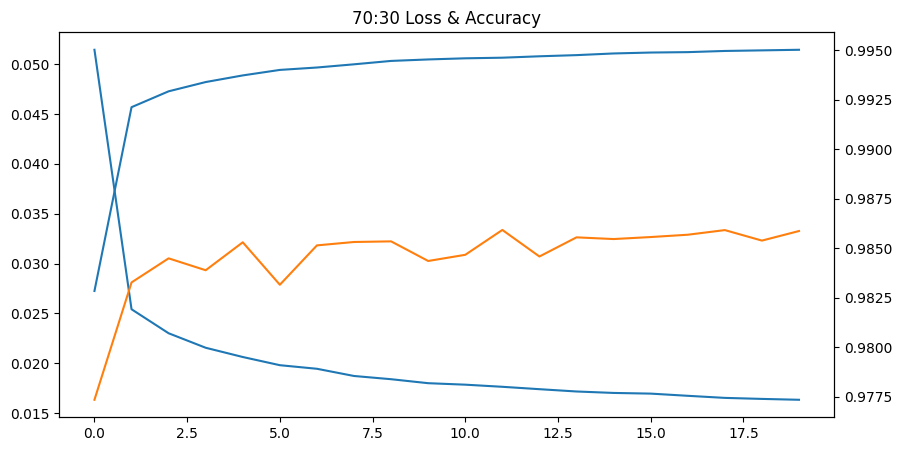

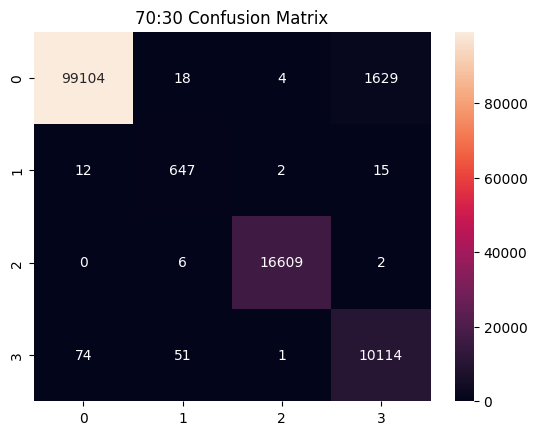

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.90      0.96      0.93       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.98      0.96    128288
weighted avg       0.99      0.99      0.99    128288



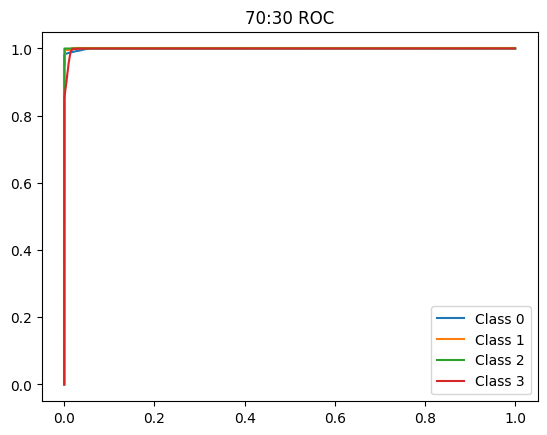

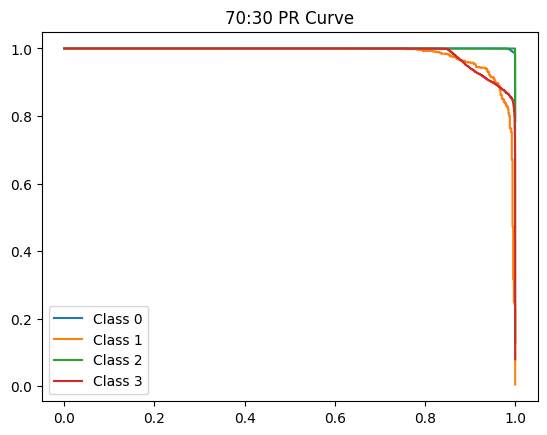

Runtime: 1456.39s
RAM Used: 415.50 MB

========== 80:20 ==========


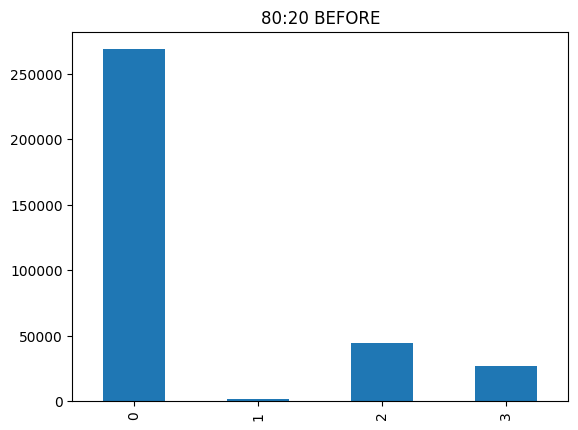

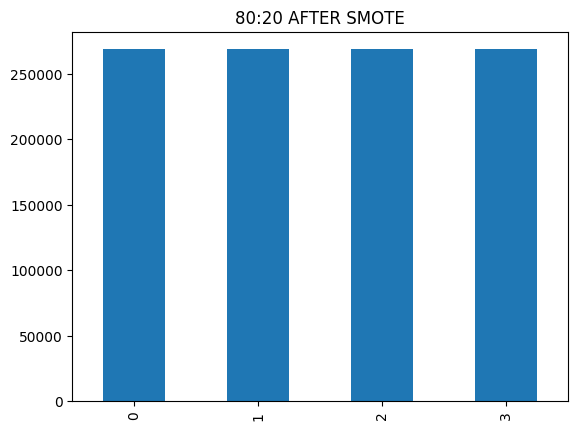

Epoch 1: Loss=0.0531, TrainAcc=0.9826, TestAcc=0.9750, ROC-AUC=0.9994
Epoch 2: Loss=0.0268, TrainAcc=0.9918, TestAcc=0.9822, ROC-AUC=0.9994
Epoch 3: Loss=0.0233, TrainAcc=0.9929, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 4: Loss=0.0218, TrainAcc=0.9934, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 5: Loss=0.0208, TrainAcc=0.9937, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 6: Loss=0.0200, TrainAcc=0.9940, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 7: Loss=0.0195, TrainAcc=0.9940, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 8: Loss=0.0189, TrainAcc=0.9943, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 9: Loss=0.0188, TrainAcc=0.9943, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 10: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9837, ROC-AUC=0.9995
Epoch 11: Loss=0.0182, TrainAcc=0.9945, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 13: Loss=0.0177, TrainAcc=0.9947, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 14: Loss=0.0174, TrainAcc=0.9948, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 15: Loss=

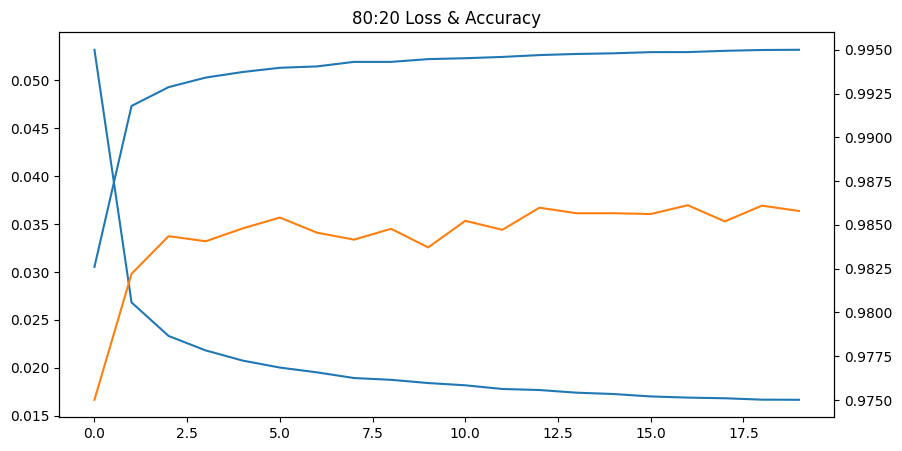

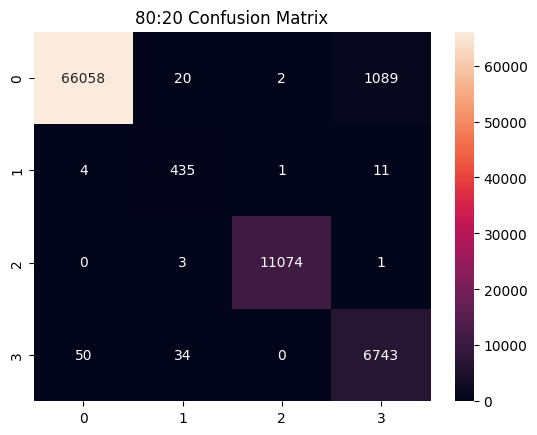

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.88      0.96      0.92       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.98      0.96     85525
weighted avg       0.99      0.99      0.99     85525



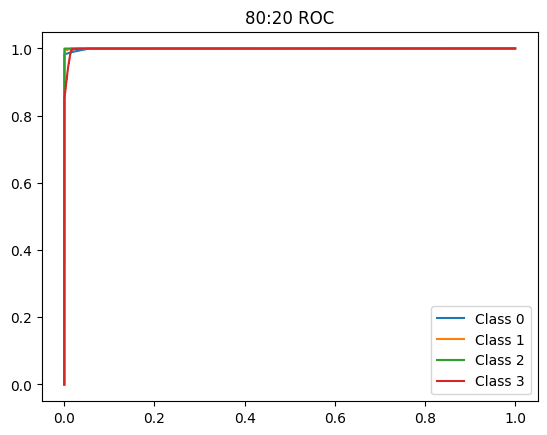

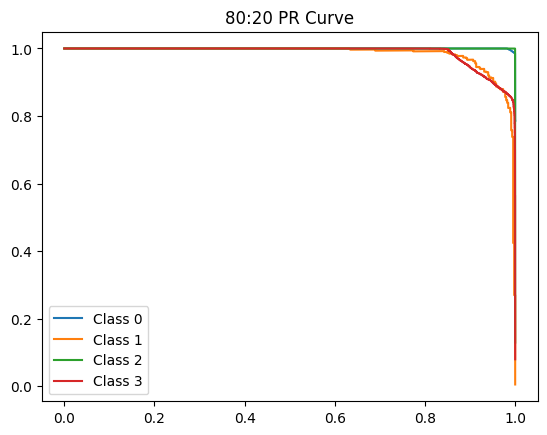

Runtime: 1626.02s
RAM Used: 468.78 MB


In [11]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", 0.4)
run_split(df, "70:30", 0.3)
run_split(df, "80:20", 0.2)

# SMOTE

In [13]:
# =============================
# MAIN PIPELINE
# =============================
def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SMOTE
    # =============================
    before_counts = pd.Series(y_train).value_counts().sort_index()
    before_counts.plot(kind="bar", title=f"{ratio_name} BEFORE SMOTE")
    plt.show()

    # =============================
    # SMOTE (STANDARD)
    # =============================
    print("\nApplying SMOTE...")

    try:
        from imblearn.over_sampling import SMOTE

        smote = SMOTE(
            sampling_strategy='auto',   # balance all classes
            k_neighbors=5,              # default, stable
            random_state=42,
            n_jobs=-1
        )

        X_train, y_train = smote.fit_resample(X_train, y_train)

    except Exception as e:
        print("⚠️ SMOTE failed, using original data:", e)

    # =============================
    # AFTER SMOTE
    # =============================
    after_counts = pd.Series(y_train).value_counts().sort_index()
    after_counts.plot(kind="bar", title=f"{ratio_name} AFTER SMOTE")
    plt.show()

    print("Class distribution after SMOTE:\n", after_counts)

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAIN LOOP
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC")
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} PR Curve")
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


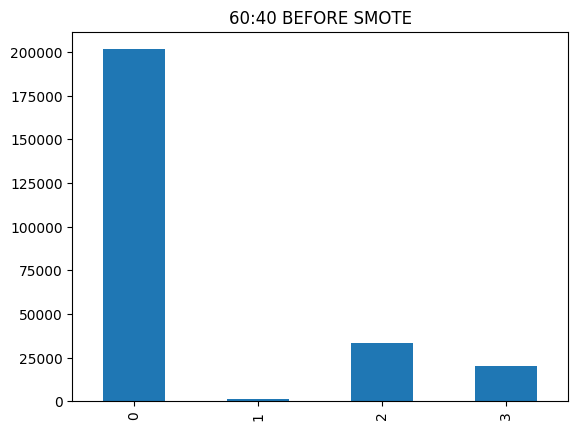


Applying SMOTE...
⚠️ SMOTE failed, using original data: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'


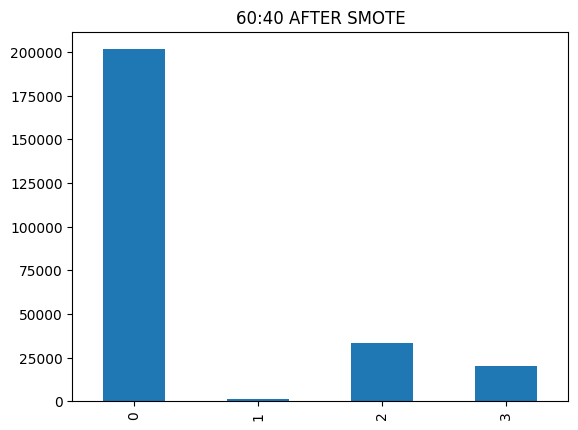

Class distribution after SMOTE:
 0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64
Epoch 1: Loss=0.2144, TrainAcc=0.9363, TestAcc=0.9316, ROC-AUC=0.9970
Epoch 2: Loss=0.0968, TrainAcc=0.9692, TestAcc=0.9677, ROC-AUC=0.9990
Epoch 3: Loss=0.0853, TrainAcc=0.9730, TestAcc=0.9719, ROC-AUC=0.9991
Epoch 4: Loss=0.0791, TrainAcc=0.9739, TestAcc=0.9770, ROC-AUC=0.9993
Epoch 5: Loss=0.0735, TrainAcc=0.9758, TestAcc=0.9718, ROC-AUC=0.9992
Epoch 6: Loss=0.0709, TrainAcc=0.9758, TestAcc=0.9735, ROC-AUC=0.9991
Epoch 7: Loss=0.0671, TrainAcc=0.9764, TestAcc=0.9556, ROC-AUC=0.9988
Epoch 8: Loss=0.0634, TrainAcc=0.9774, TestAcc=0.9755, ROC-AUC=0.9993
Epoch 9: Loss=0.0621, TrainAcc=0.9776, TestAcc=0.9800, ROC-AUC=0.9994
Epoch 10: Loss=0.0596, TrainAcc=0.9783, TestAcc=0.9810, ROC-AUC=0.9995
Epoch 11: Loss=0.0597, TrainAcc=0.9791, TestAcc=0.9817, ROC-AUC=0.9995
Epoch 12: Loss=0.0591, TrainAcc=0.9793, TestAcc=0.9830, ROC-AUC=0.9995
Epoch 13: Loss=0.0573, TrainAcc=0.9797, TestAcc=0.

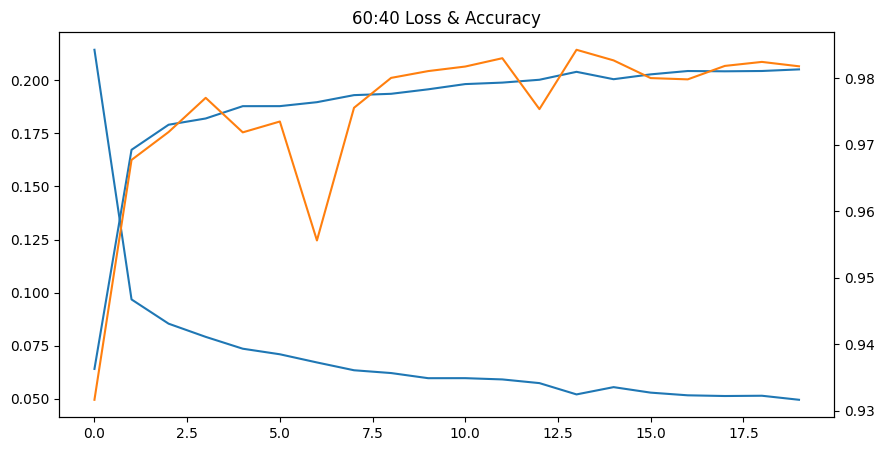

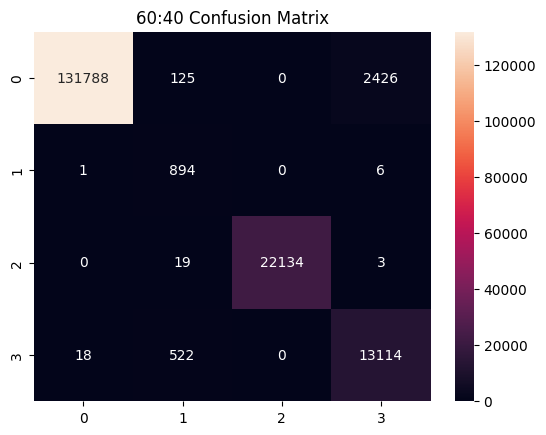

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.57      0.99      0.73       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.96      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.85      0.98      0.90    171050
weighted avg       0.99      0.98      0.98    171050



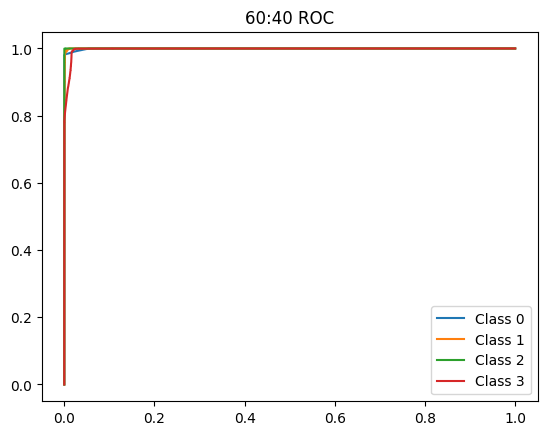

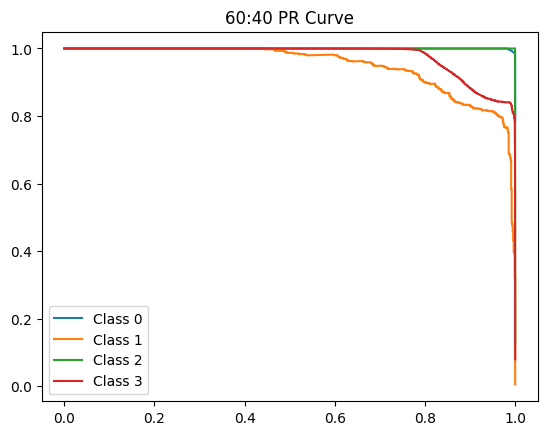

Runtime: 450.40s
RAM Used: 150.09 MB

========== 70:30 ==========


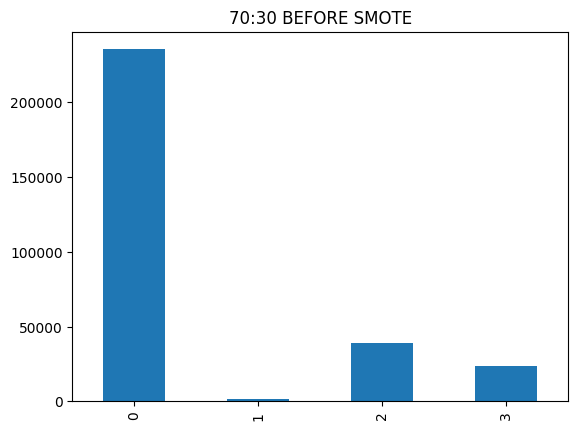


Applying SMOTE...
⚠️ SMOTE failed, using original data: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'


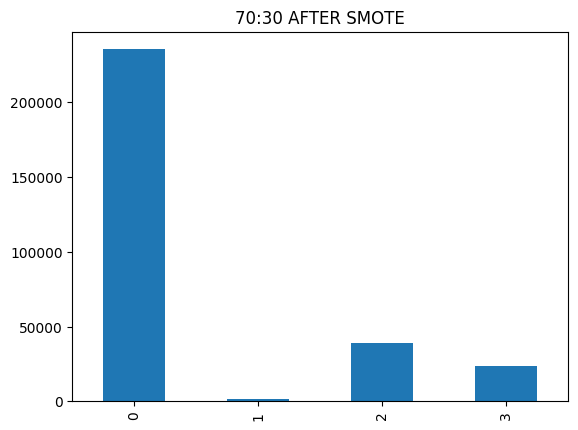

Class distribution after SMOTE:
 0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64
Epoch 1: Loss=0.2002, TrainAcc=0.9423, TestAcc=0.9678, ROC-AUC=0.9989
Epoch 2: Loss=0.0972, TrainAcc=0.9700, TestAcc=0.9785, ROC-AUC=0.9992
Epoch 3: Loss=0.0859, TrainAcc=0.9729, TestAcc=0.9734, ROC-AUC=0.9992
Epoch 4: Loss=0.0755, TrainAcc=0.9751, TestAcc=0.9766, ROC-AUC=0.9993
Epoch 5: Loss=0.0713, TrainAcc=0.9766, TestAcc=0.9797, ROC-AUC=0.9994
Epoch 6: Loss=0.0658, TrainAcc=0.9774, TestAcc=0.9785, ROC-AUC=0.9995
Epoch 7: Loss=0.0642, TrainAcc=0.9781, TestAcc=0.9807, ROC-AUC=0.9994
Epoch 8: Loss=0.0606, TrainAcc=0.9792, TestAcc=0.9806, ROC-AUC=0.9994
Epoch 9: Loss=0.0571, TrainAcc=0.9796, TestAcc=0.9794, ROC-AUC=0.9994
Epoch 10: Loss=0.0568, TrainAcc=0.9801, TestAcc=0.9805, ROC-AUC=0.9994
Epoch 11: Loss=0.0546, TrainAcc=0.9803, TestAcc=0.9807, ROC-AUC=0.9994
Epoch 12: Loss=0.0557, TrainAcc=0.9797, TestAcc=0.9797, ROC-AUC=0.9994
Epoch 13: Loss=0.0527, TrainAcc=0.9806, TestAcc=0.

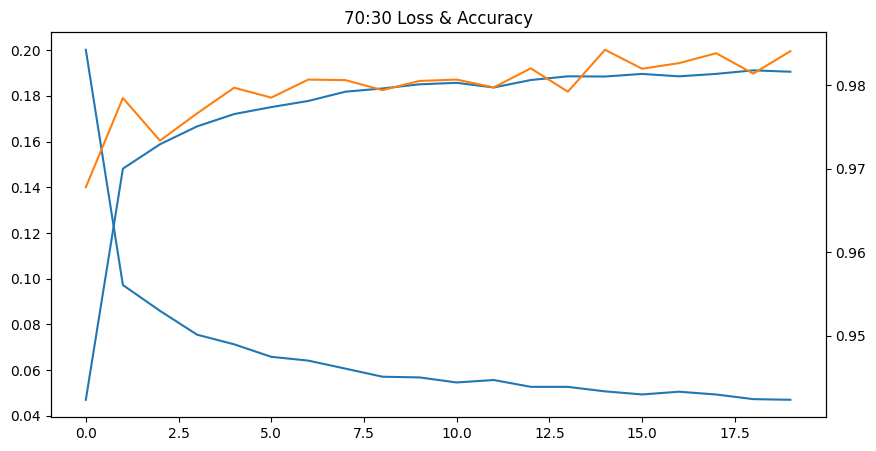

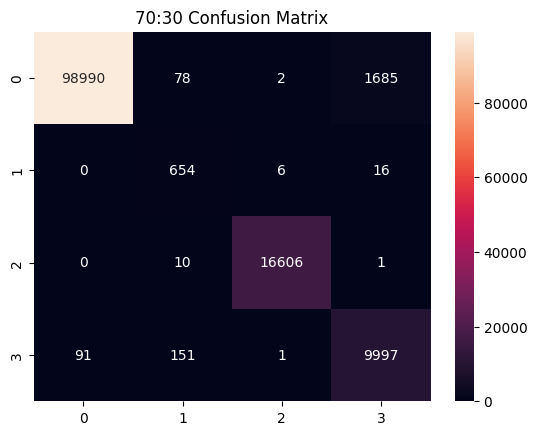

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.73      0.97      0.83       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.98      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.90      0.98      0.93    128288
weighted avg       0.99      0.98      0.98    128288



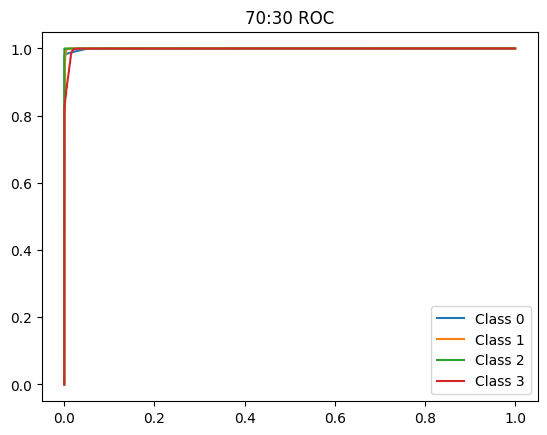

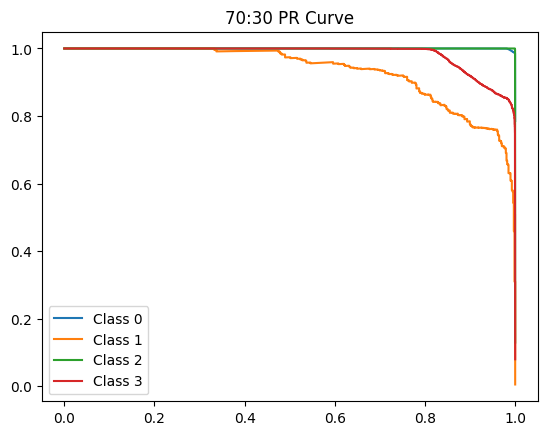

Runtime: 490.38s
RAM Used: 133.12 MB

========== 80:20 ==========


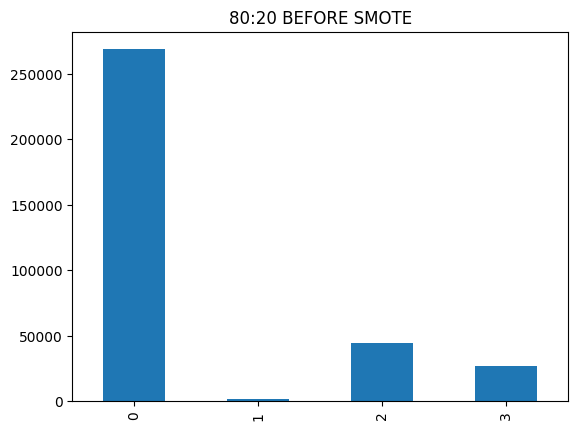


Applying SMOTE...
⚠️ SMOTE failed, using original data: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'


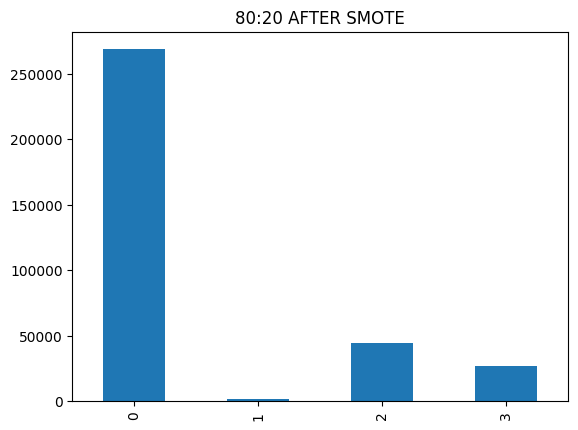

Class distribution after SMOTE:
 0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64
Epoch 1: Loss=0.1845, TrainAcc=0.9423, TestAcc=0.9556, ROC-AUC=0.9988
Epoch 2: Loss=0.0948, TrainAcc=0.9700, TestAcc=0.9767, ROC-AUC=0.9992
Epoch 3: Loss=0.0839, TrainAcc=0.9726, TestAcc=0.9788, ROC-AUC=0.9992
Epoch 4: Loss=0.0755, TrainAcc=0.9747, TestAcc=0.9753, ROC-AUC=0.9993
Epoch 5: Loss=0.0689, TrainAcc=0.9760, TestAcc=0.9723, ROC-AUC=0.9992
Epoch 6: Loss=0.0676, TrainAcc=0.9771, TestAcc=0.9739, ROC-AUC=0.9992
Epoch 7: Loss=0.0669, TrainAcc=0.9772, TestAcc=0.9807, ROC-AUC=0.9992
Epoch 8: Loss=0.0614, TrainAcc=0.9785, TestAcc=0.9764, ROC-AUC=0.9992
Epoch 9: Loss=0.0591, TrainAcc=0.9794, TestAcc=0.9788, ROC-AUC=0.9992
Epoch 10: Loss=0.0578, TrainAcc=0.9799, TestAcc=0.9831, ROC-AUC=0.9995
Epoch 11: Loss=0.0558, TrainAcc=0.9799, TestAcc=0.9814, ROC-AUC=0.9995
Epoch 12: Loss=0.0535, TrainAcc=0.9804, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 13: Loss=0.0532, TrainAcc=0.9807, TestAcc=0.

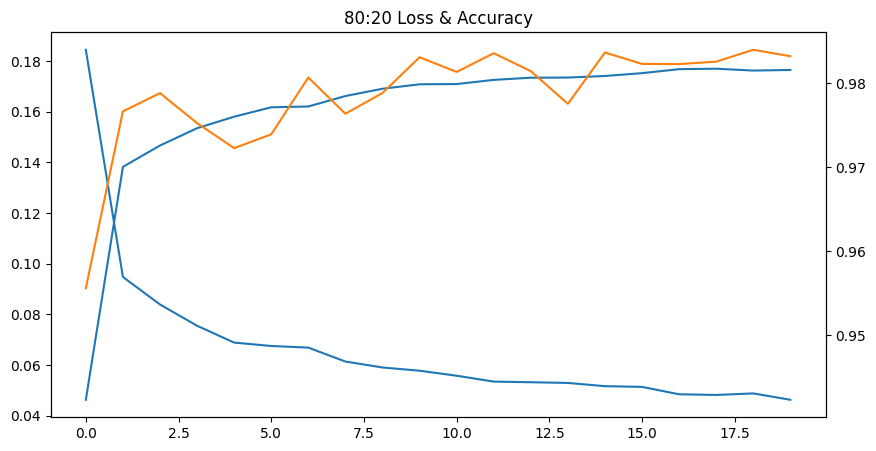

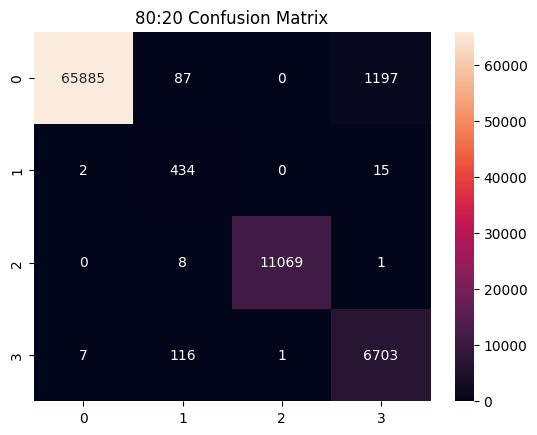

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.67      0.96      0.79       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.98      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.88      0.98      0.92     85525
weighted avg       0.99      0.98      0.98     85525



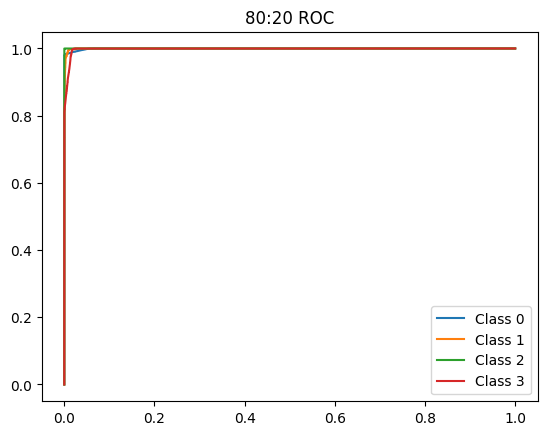

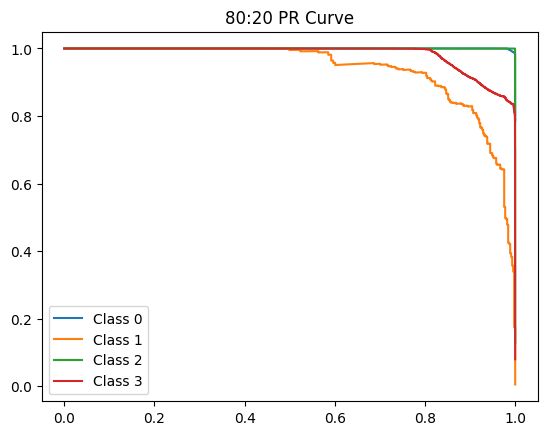

Runtime: 529.23s
RAM Used: 140.99 MB


In [14]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", 0.4)
run_split_smote(df, "70:30", 0.3)
run_split_smote(df, "80:20", 0.2)

# ADASYN

In [15]:
# =============================
# MAIN PIPELINE
# =============================
def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE ADASYN
    # =============================
    before_counts = pd.Series(y_train).value_counts().sort_index()
    before_counts.plot(kind="bar", title=f"{ratio_name} BEFORE ADASYN")
    plt.show()

    # =============================
    # ADASYN (ADAPTIVE SMOTE)
    # =============================
    print("\nApplying ADASYN...")

    try:
        from imblearn.over_sampling import ADASYN

        adasyn = ADASYN(
            sampling_strategy='auto',   # balance classes
            n_neighbors=5,              # default
            random_state=42,
            n_jobs=-1
        )

        X_train, y_train = adasyn.fit_resample(X_train, y_train)

    except Exception as e:
        print("⚠️ ADASYN failed, using original data:", e)

    # =============================
    # AFTER ADASYN
    # =============================
    after_counts = pd.Series(y_train).value_counts().sort_index()
    after_counts.plot(kind="bar", title=f"{ratio_name} AFTER ADASYN")
    plt.show()

    print("Class distribution after ADASYN:\n", after_counts)

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAIN LOOP
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC")
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} PR Curve")
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


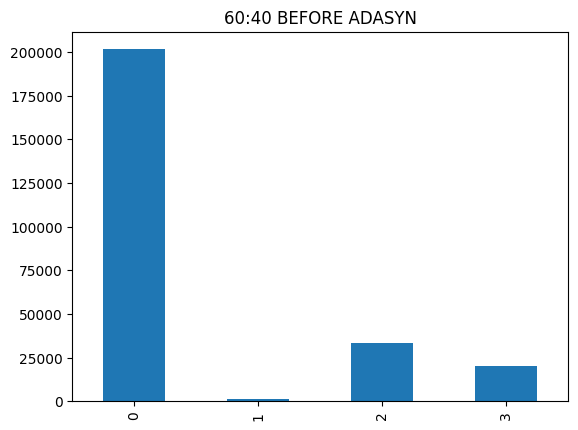


Applying ADASYN...
⚠️ ADASYN failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


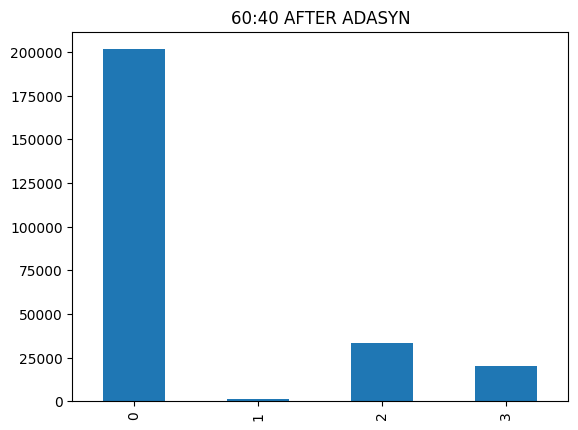

Class distribution after ADASYN:
 0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64
Epoch 1: Loss=0.2114, TrainAcc=0.9305, TestAcc=0.9604, ROC-AUC=0.9986
Epoch 2: Loss=0.1051, TrainAcc=0.9652, TestAcc=0.9696, ROC-AUC=0.9989
Epoch 3: Loss=0.0928, TrainAcc=0.9705, TestAcc=0.9673, ROC-AUC=0.9989
Epoch 4: Loss=0.0826, TrainAcc=0.9728, TestAcc=0.9744, ROC-AUC=0.9991
Epoch 5: Loss=0.0780, TrainAcc=0.9740, TestAcc=0.9672, ROC-AUC=0.9988
Epoch 6: Loss=0.0717, TrainAcc=0.9750, TestAcc=0.9720, ROC-AUC=0.9992
Epoch 7: Loss=0.0691, TrainAcc=0.9755, TestAcc=0.9726, ROC-AUC=0.9991
Epoch 8: Loss=0.0648, TrainAcc=0.9768, TestAcc=0.9791, ROC-AUC=0.9993
Epoch 9: Loss=0.0641, TrainAcc=0.9771, TestAcc=0.9765, ROC-AUC=0.9993
Epoch 10: Loss=0.0611, TrainAcc=0.9777, TestAcc=0.9790, ROC-AUC=0.9994
Epoch 11: Loss=0.0581, TrainAcc=0.9784, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 12: Loss=0.0578, TrainAcc=0.9790, TestAcc=0.9777, ROC-AUC=0.9993
Epoch 13: Loss=0.0581, TrainAcc=0.9793, TestAcc=0

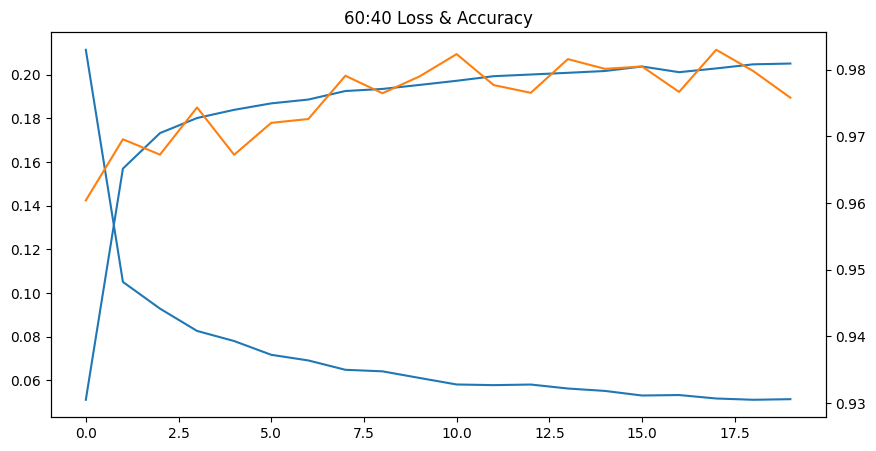

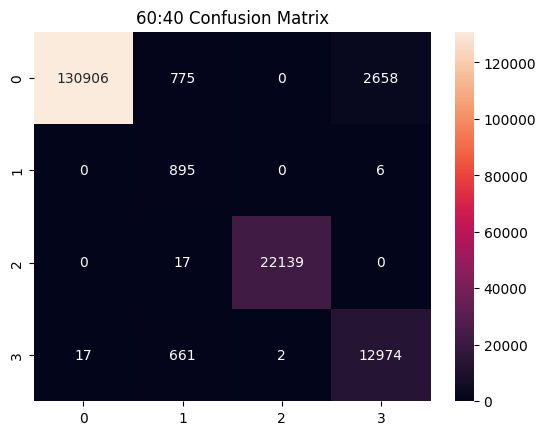

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    134339
           1       0.38      0.99      0.55       901
           2       1.00      1.00      1.00     22156
           3       0.83      0.95      0.89     13654

    accuracy                           0.98    171050
   macro avg       0.80      0.98      0.86    171050
weighted avg       0.98      0.98      0.98    171050



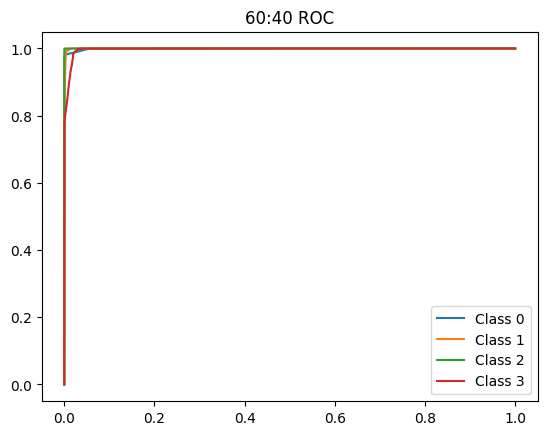

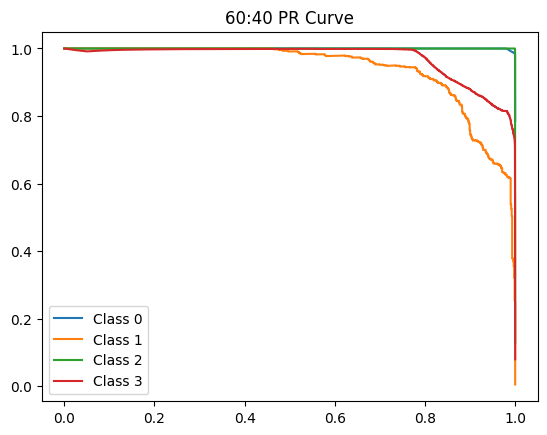

Runtime: 454.82s
RAM Used: 171.29 MB

========== 70:30 ==========


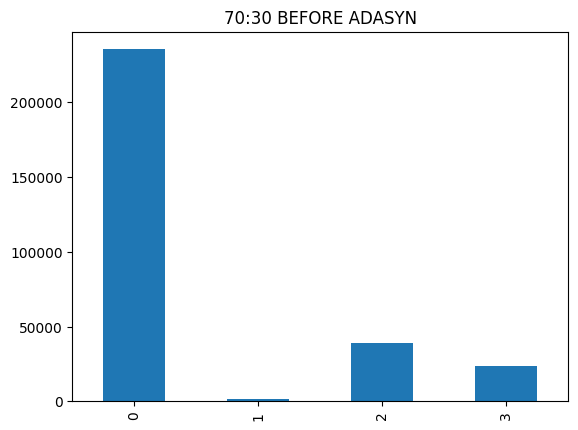


Applying ADASYN...
⚠️ ADASYN failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


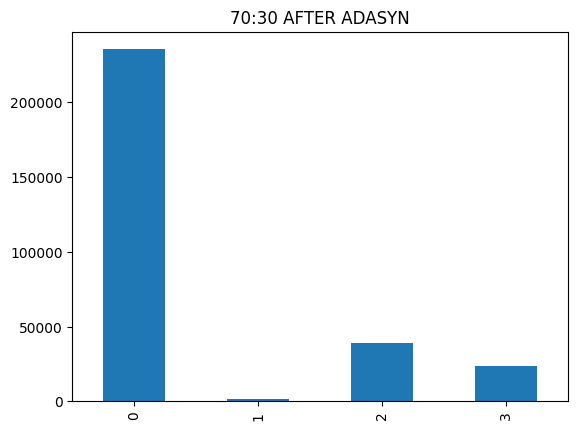

Class distribution after ADASYN:
 0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64
Epoch 1: Loss=0.1978, TrainAcc=0.9360, TestAcc=0.9725, ROC-AUC=0.9990
Epoch 2: Loss=0.0953, TrainAcc=0.9691, TestAcc=0.9806, ROC-AUC=0.9991
Epoch 3: Loss=0.0835, TrainAcc=0.9728, TestAcc=0.9715, ROC-AUC=0.9990
Epoch 4: Loss=0.0773, TrainAcc=0.9740, TestAcc=0.9779, ROC-AUC=0.9993
Epoch 5: Loss=0.0743, TrainAcc=0.9752, TestAcc=0.9750, ROC-AUC=0.9994
Epoch 6: Loss=0.0691, TrainAcc=0.9766, TestAcc=0.9811, ROC-AUC=0.9994
Epoch 7: Loss=0.0685, TrainAcc=0.9767, TestAcc=0.9661, ROC-AUC=0.9990
Epoch 8: Loss=0.0645, TrainAcc=0.9783, TestAcc=0.9762, ROC-AUC=0.9992
Epoch 9: Loss=0.0627, TrainAcc=0.9784, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 10: Loss=0.0608, TrainAcc=0.9789, TestAcc=0.9778, ROC-AUC=0.9993
Epoch 11: Loss=0.0564, TrainAcc=0.9796, TestAcc=0.9786, ROC-AUC=0.9994
Epoch 12: Loss=0.0530, TrainAcc=0.9801, TestAcc=0.9799, ROC-AUC=0.9994
Epoch 13: Loss=0.0535, TrainAcc=0.9805, TestAcc=0

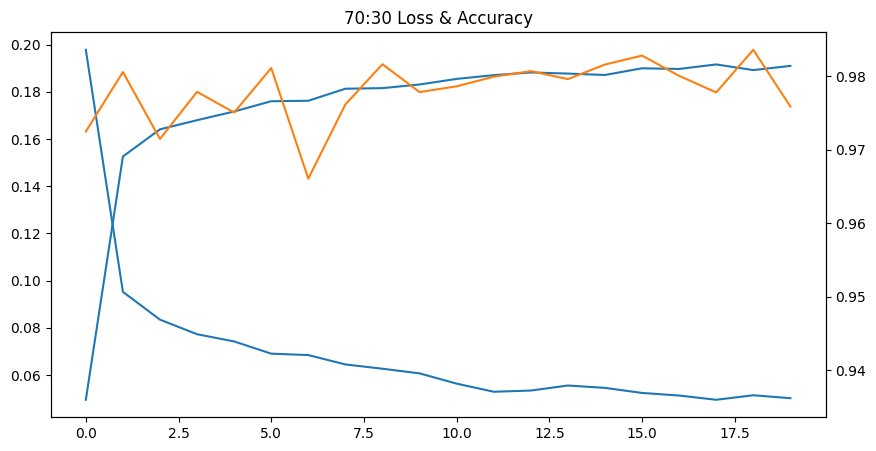

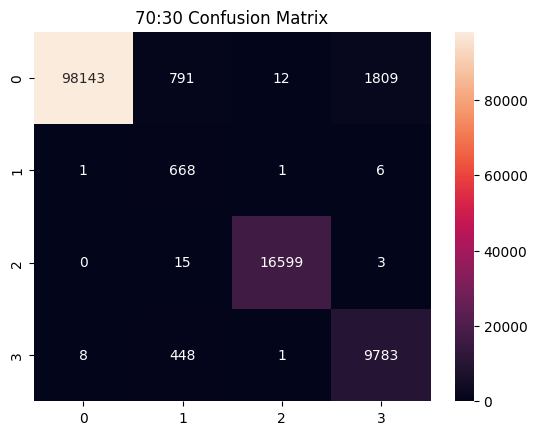

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    100755
           1       0.35      0.99      0.51       676
           2       1.00      1.00      1.00     16617
           3       0.84      0.96      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.80      0.98      0.85    128288
weighted avg       0.98      0.98      0.98    128288



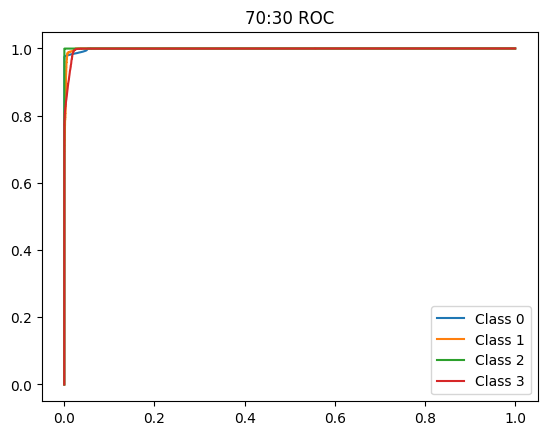

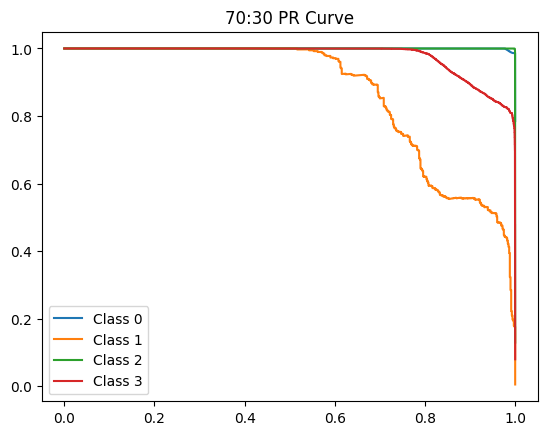

Runtime: 489.20s
RAM Used: 150.10 MB

========== 80:20 ==========


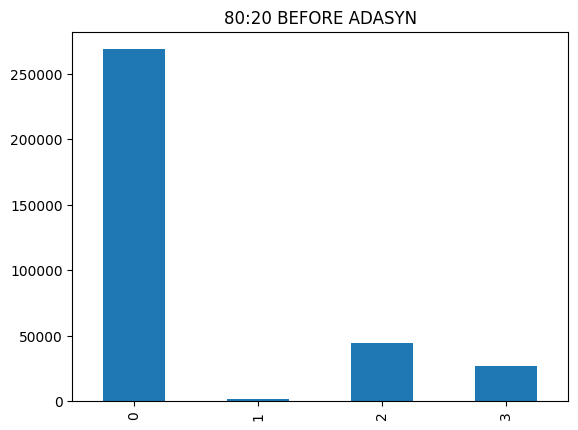


Applying ADASYN...
⚠️ ADASYN failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


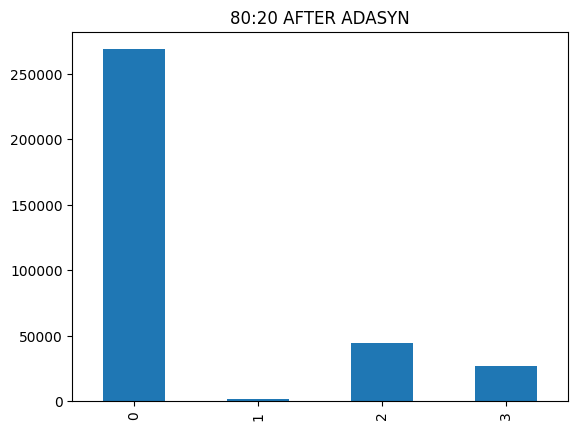

Class distribution after ADASYN:
 0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64
Epoch 1: Loss=0.1842, TrainAcc=0.9467, TestAcc=0.9748, ROC-AUC=0.9990
Epoch 2: Loss=0.0913, TrainAcc=0.9718, TestAcc=0.9674, ROC-AUC=0.9989
Epoch 3: Loss=0.0783, TrainAcc=0.9749, TestAcc=0.9763, ROC-AUC=0.9991
Epoch 4: Loss=0.0739, TrainAcc=0.9753, TestAcc=0.9779, ROC-AUC=0.9994
Epoch 5: Loss=0.0700, TrainAcc=0.9761, TestAcc=0.9732, ROC-AUC=0.9992
Epoch 6: Loss=0.0658, TrainAcc=0.9771, TestAcc=0.9757, ROC-AUC=0.9992
Epoch 7: Loss=0.0620, TrainAcc=0.9780, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 8: Loss=0.0603, TrainAcc=0.9788, TestAcc=0.9801, ROC-AUC=0.9994
Epoch 9: Loss=0.0598, TrainAcc=0.9790, TestAcc=0.9815, ROC-AUC=0.9995
Epoch 10: Loss=0.0561, TrainAcc=0.9799, TestAcc=0.9809, ROC-AUC=0.9994
Epoch 11: Loss=0.0550, TrainAcc=0.9803, TestAcc=0.9825, ROC-AUC=0.9995
Epoch 12: Loss=0.0520, TrainAcc=0.9808, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 13: Loss=0.0529, TrainAcc=0.9810, TestAcc=0

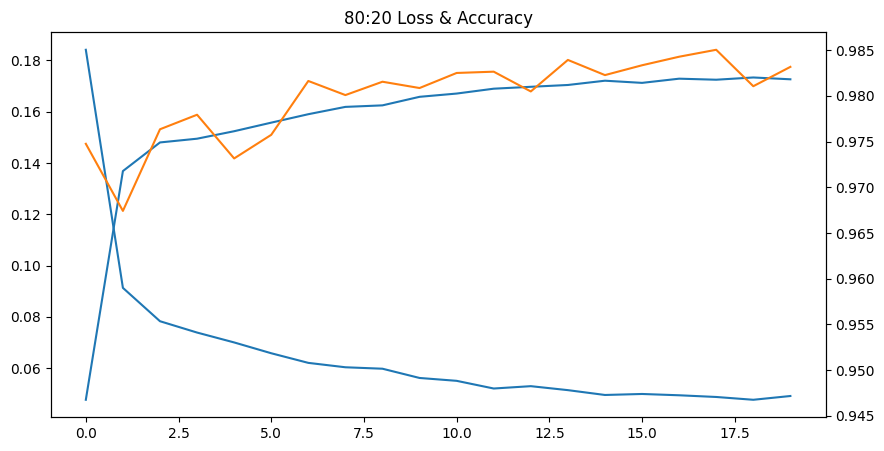

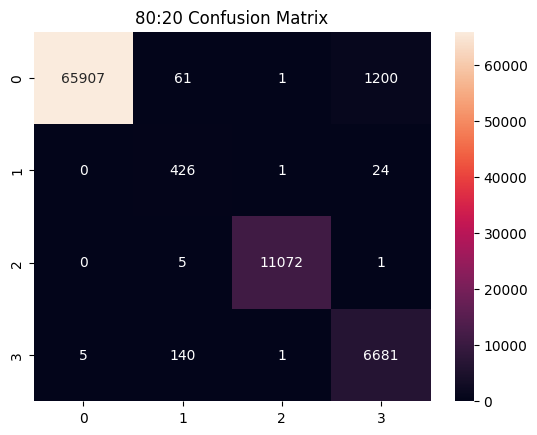

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.67      0.94      0.79       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.98      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.88      0.98      0.92     85525
weighted avg       0.99      0.98      0.98     85525



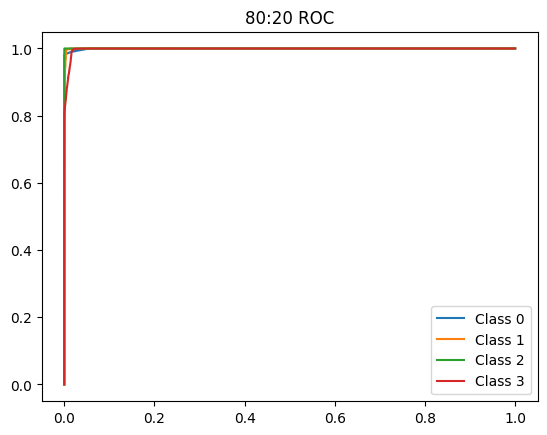

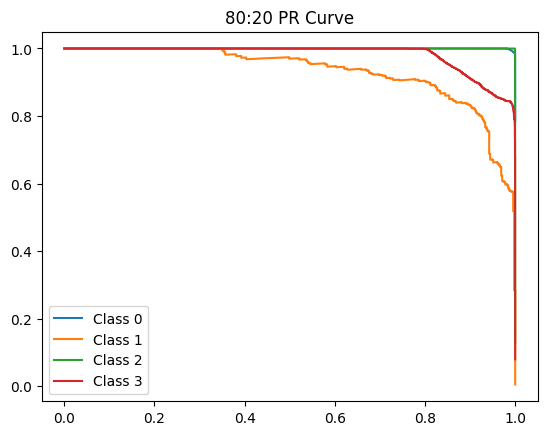

Runtime: 533.06s
RAM Used: 140.94 MB


In [16]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", 0.4)
run_split_adasyn(df, "70:30", 0.3)
run_split_adasyn(df, "80:20", 0.2)

# ADASYN + Tomek_Links

In [17]:
# =============================
# MAIN PIPELINE
# =============================
def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    before_counts = pd.Series(y_train).value_counts().sort_index()
    before_counts.plot(kind="bar", title=f"{ratio_name} BEFORE SAMPLING")
    plt.show()

    # =============================
    # ADASYN + TOMEK LINKS
    # =============================
    print("\nApplying ADASYN + TomekLinks...")

    try:
        from imblearn.over_sampling import ADASYN
        from imblearn.under_sampling import TomekLinks

        # Step 1: ADASYN (oversample)
        adasyn = ADASYN(
            sampling_strategy='auto',
            n_neighbors=5,
            random_state=42,
            n_jobs=-1
        )
        X_res, y_res = adasyn.fit_resample(X_train, y_train)

        # Step 2: Tomek Links (clean noise)
        tomek = TomekLinks(n_jobs=-1)
        X_train, y_train = tomek.fit_resample(X_res, y_res)

    except Exception as e:
        print("⚠️ ADASYN + TomekLinks failed, using original data:", e)

    # =============================
    # AFTER SAMPLING
    # =============================
    after_counts = pd.Series(y_train).value_counts().sort_index()
    after_counts.plot(kind="bar", title=f"{ratio_name} AFTER ADASYN + TOMEK")
    plt.show()

    print("Class distribution after ADASYN + Tomek:\n", after_counts)

    # =============================
    # SCALING
    # =============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAIN LOOP
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC")
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} PR Curve")
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"Runtime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


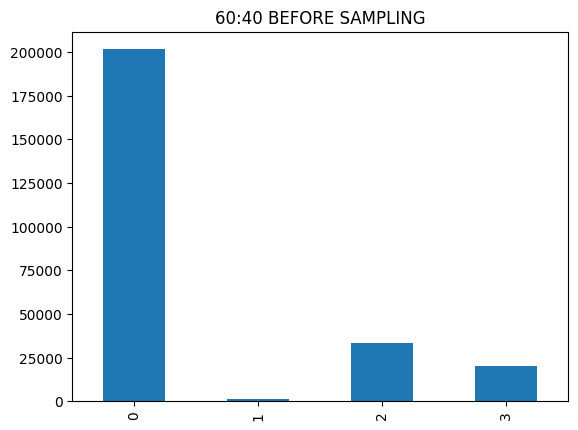


Applying ADASYN + TomekLinks...
⚠️ ADASYN + TomekLinks failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


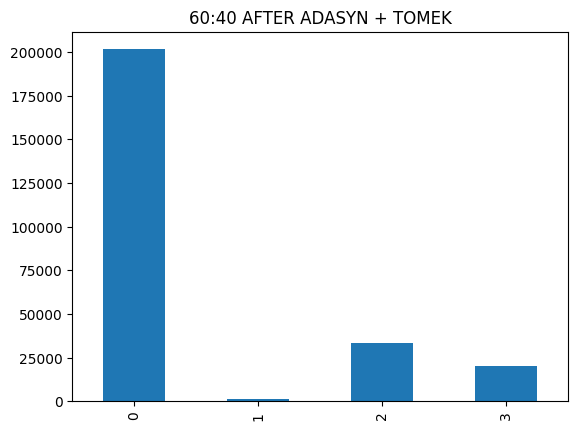

Class distribution after ADASYN + Tomek:
 0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64
Epoch 1: Loss=0.2122, TrainAcc=0.9332, TestAcc=0.9728, ROC-AUC=0.9988
Epoch 2: Loss=0.1046, TrainAcc=0.9680, TestAcc=0.9640, ROC-AUC=0.9986
Epoch 3: Loss=0.0929, TrainAcc=0.9710, TestAcc=0.9752, ROC-AUC=0.9991
Epoch 4: Loss=0.0809, TrainAcc=0.9734, TestAcc=0.9696, ROC-AUC=0.9990
Epoch 5: Loss=0.0771, TrainAcc=0.9746, TestAcc=0.9722, ROC-AUC=0.9990
Epoch 6: Loss=0.0706, TrainAcc=0.9758, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 7: Loss=0.0685, TrainAcc=0.9761, TestAcc=0.9716, ROC-AUC=0.9992
Epoch 8: Loss=0.0658, TrainAcc=0.9767, TestAcc=0.9775, ROC-AUC=0.9993
Epoch 9: Loss=0.0630, TrainAcc=0.9775, TestAcc=0.9810, ROC-AUC=0.9994
Epoch 10: Loss=0.0626, TrainAcc=0.9779, TestAcc=0.9801, ROC-AUC=0.9994
Epoch 11: Loss=0.0606, TrainAcc=0.9785, TestAcc=0.9743, ROC-AUC=0.9992
Epoch 12: Loss=0.0621, TrainAcc=0.9789, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 13: Loss=0.0597, TrainAcc=0.9793, T

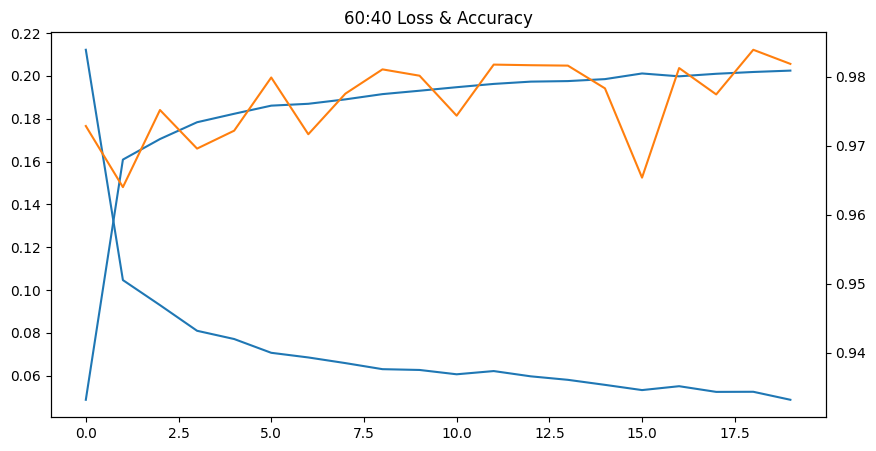

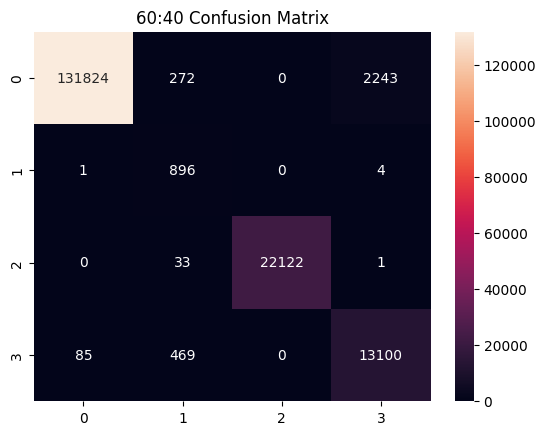

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.54      0.99      0.70       901
           2       1.00      1.00      1.00     22156
           3       0.85      0.96      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.85      0.98      0.90    171050
weighted avg       0.99      0.98      0.98    171050



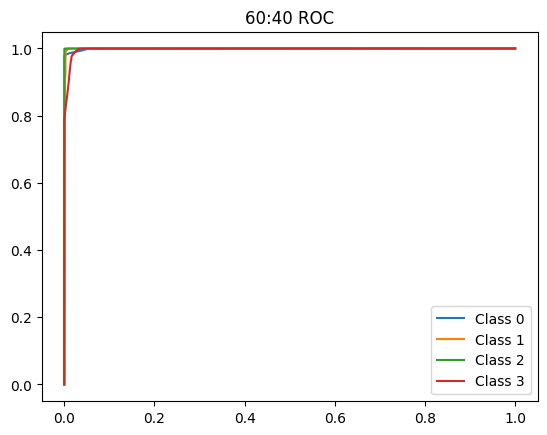

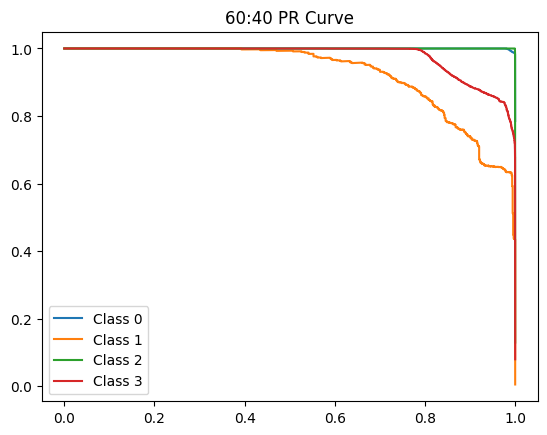

Runtime: 457.61s
RAM Used: 189.77 MB

========== 70:30 ==========


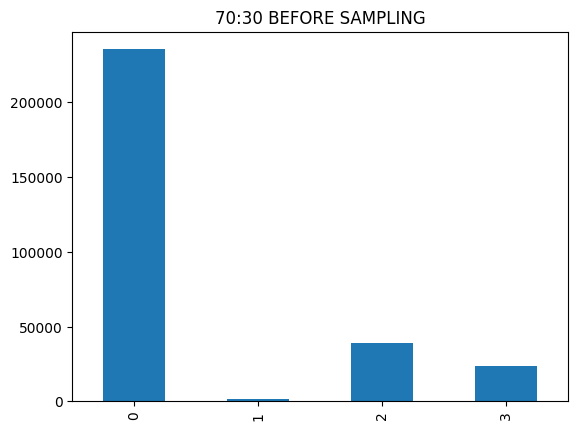


Applying ADASYN + TomekLinks...
⚠️ ADASYN + TomekLinks failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


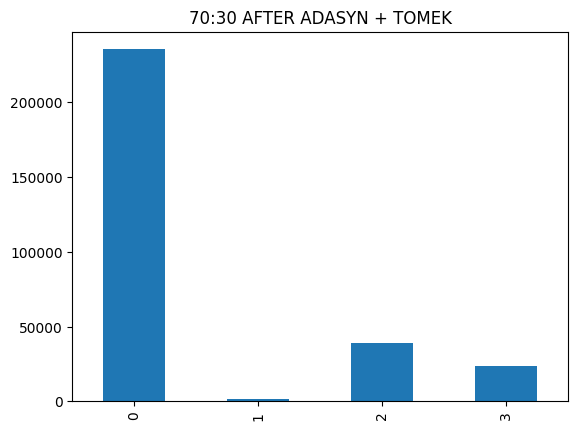

Class distribution after ADASYN + Tomek:
 0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64
Epoch 1: Loss=0.1979, TrainAcc=0.9459, TestAcc=0.9727, ROC-AUC=0.9988
Epoch 2: Loss=0.1002, TrainAcc=0.9704, TestAcc=0.9735, ROC-AUC=0.9991
Epoch 3: Loss=0.0851, TrainAcc=0.9727, TestAcc=0.9727, ROC-AUC=0.9992
Epoch 4: Loss=0.0801, TrainAcc=0.9742, TestAcc=0.9785, ROC-AUC=0.9993
Epoch 5: Loss=0.0720, TrainAcc=0.9755, TestAcc=0.9782, ROC-AUC=0.9994
Epoch 6: Loss=0.0677, TrainAcc=0.9766, TestAcc=0.9739, ROC-AUC=0.9992
Epoch 7: Loss=0.0648, TrainAcc=0.9774, TestAcc=0.9742, ROC-AUC=0.9991
Epoch 8: Loss=0.0620, TrainAcc=0.9783, TestAcc=0.9761, ROC-AUC=0.9994
Epoch 9: Loss=0.0601, TrainAcc=0.9782, TestAcc=0.9811, ROC-AUC=0.9995
Epoch 10: Loss=0.0567, TrainAcc=0.9794, TestAcc=0.9826, ROC-AUC=0.9995
Epoch 11: Loss=0.0591, TrainAcc=0.9794, TestAcc=0.9820, ROC-AUC=0.9994
Epoch 12: Loss=0.0553, TrainAcc=0.9803, TestAcc=0.9739, ROC-AUC=0.9993
Epoch 13: Loss=0.0551, TrainAcc=0.9800, T

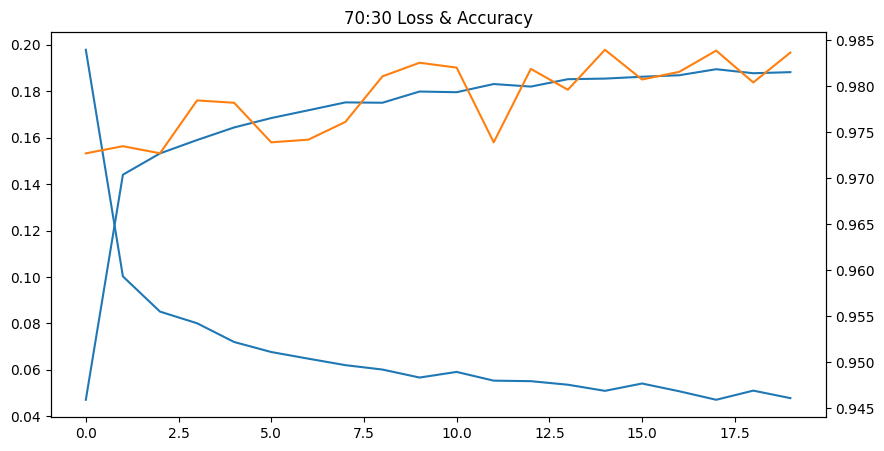

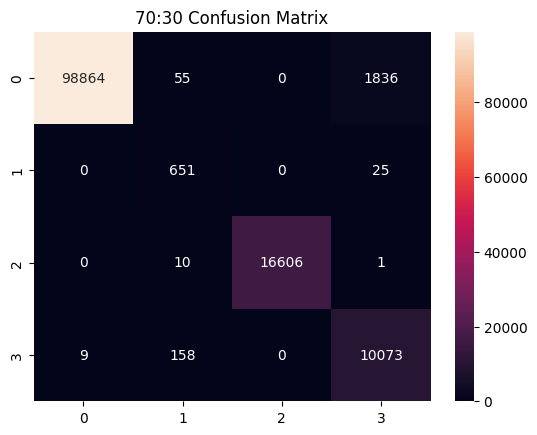

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.74      0.96      0.84       676
           2       1.00      1.00      1.00     16617
           3       0.84      0.98      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.90      0.98      0.93    128288
weighted avg       0.99      0.98      0.98    128288



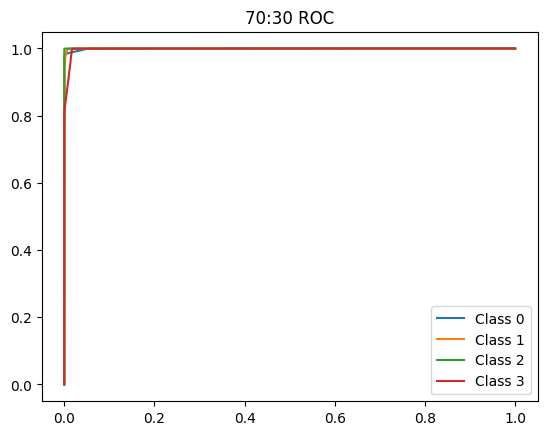

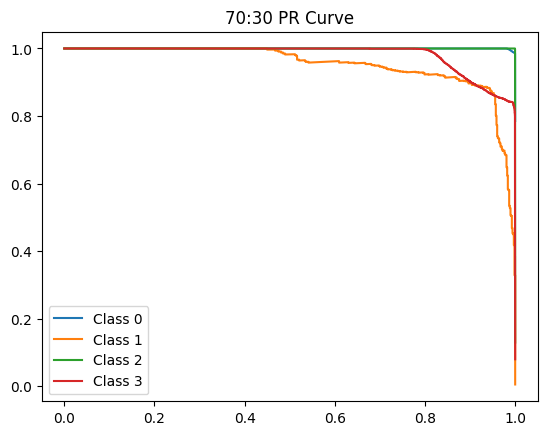

Runtime: 495.98s
RAM Used: 183.31 MB

========== 80:20 ==========


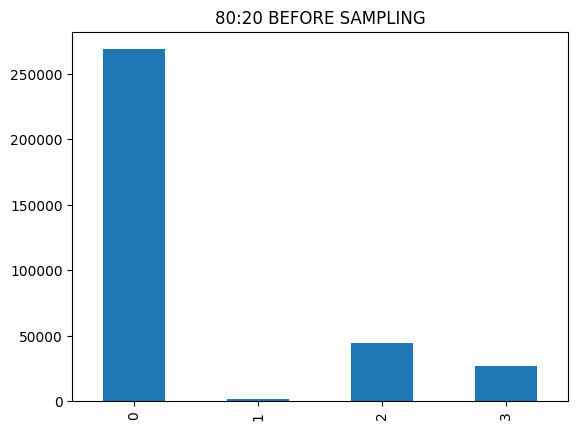


Applying ADASYN + TomekLinks...
⚠️ ADASYN + TomekLinks failed, using original data: ADASYN.__init__() got an unexpected keyword argument 'n_jobs'


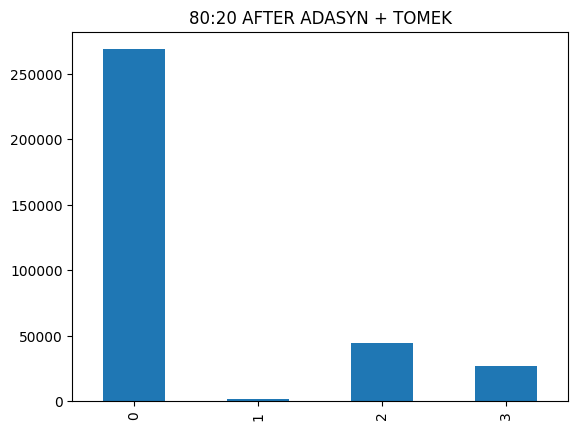

Class distribution after ADASYN + Tomek:
 0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64
Epoch 1: Loss=0.1811, TrainAcc=0.9439, TestAcc=0.9737, ROC-AUC=0.9990
Epoch 2: Loss=0.0947, TrainAcc=0.9710, TestAcc=0.9700, ROC-AUC=0.9989
Epoch 3: Loss=0.0823, TrainAcc=0.9737, TestAcc=0.9765, ROC-AUC=0.9992
Epoch 4: Loss=0.0734, TrainAcc=0.9761, TestAcc=0.9791, ROC-AUC=0.9994
Epoch 5: Loss=0.0671, TrainAcc=0.9776, TestAcc=0.9822, ROC-AUC=0.9995
Epoch 6: Loss=0.0647, TrainAcc=0.9785, TestAcc=0.9826, ROC-AUC=0.9995
Epoch 7: Loss=0.0614, TrainAcc=0.9793, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 8: Loss=0.0614, TrainAcc=0.9790, TestAcc=0.9737, ROC-AUC=0.9991
Epoch 9: Loss=0.0589, TrainAcc=0.9800, TestAcc=0.9819, ROC-AUC=0.9995
Epoch 10: Loss=0.0568, TrainAcc=0.9802, TestAcc=0.9817, ROC-AUC=0.9995
Epoch 11: Loss=0.0530, TrainAcc=0.9804, TestAcc=0.9811, ROC-AUC=0.9994
Epoch 12: Loss=0.0528, TrainAcc=0.9809, TestAcc=0.9834, ROC-AUC=0.9995
Epoch 13: Loss=0.0531, TrainAcc=0.9811, T

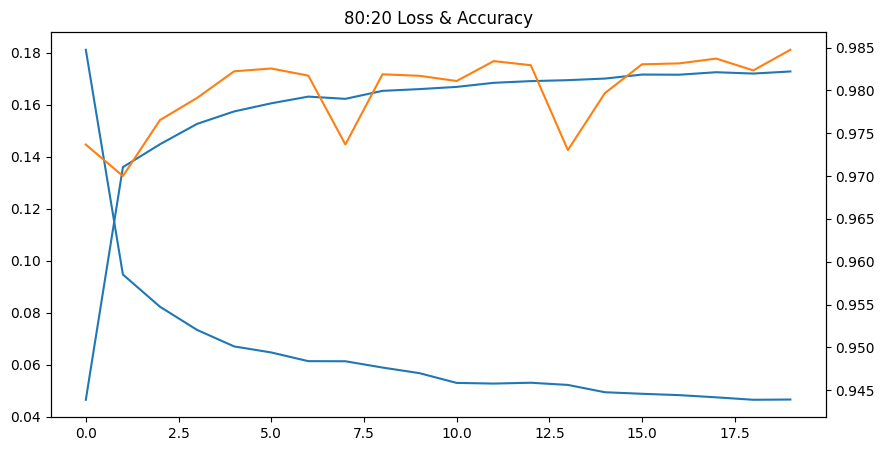

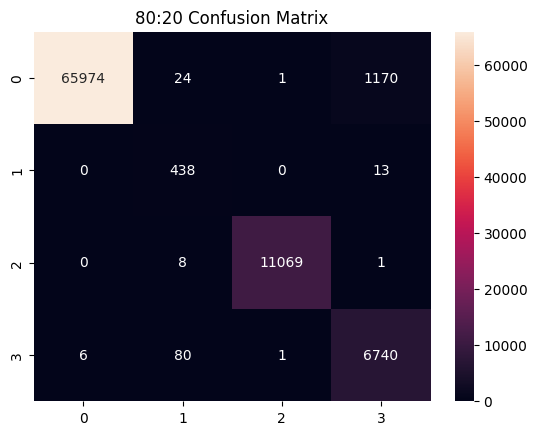

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.80      0.97      0.88       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.91      0.98      0.94     85525
weighted avg       0.99      0.98      0.99     85525



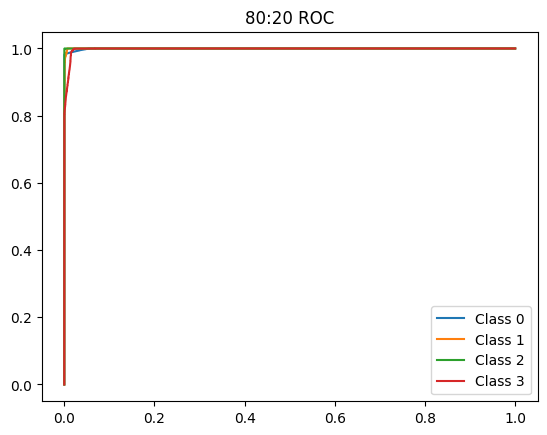

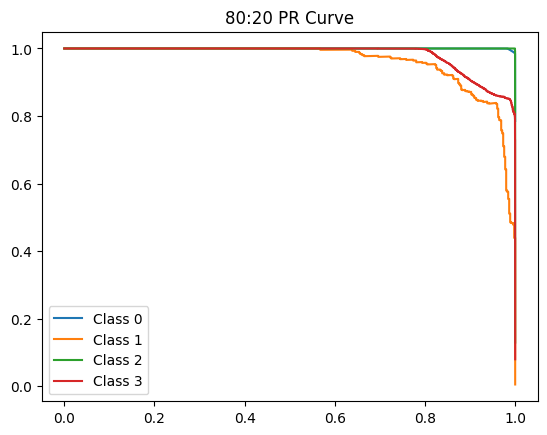

Runtime: 533.81s
RAM Used: 172.26 MB


In [18]:
# =============================
# RUN
# =============================
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", 0.4)
run_split_adasyn_tomek(df, "70:30", 0.3)
run_split_adasyn_tomek(df, "80:20", 0.2)

In [20]:
!pip install numpy